# Clustering Case Study — Human Activity Recognition (HAR) Dataset

**Dataset:** 561 smartphone accelerometer/gyroscope features, 7352 samples, 6 real activity classes (`WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS`, `SITTING`, `STANDING`, `LAYING`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')           

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42                           
np.random.seed(RANDOM_STATE)                 

## 1. Loading the Data


In [2]:
har = pd.read_csv('../data/train.csv')
print('HAR shape:', har.shape)
print(har['Activity'].value_counts())
har.head()

HAR shape: (7352, 563)
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


## 2. Preprocessing

The 561 HAR features are already roughly in the -1 to 1 range, but not all on exactly the same scale — and there are far more features than we can sensibly plot, so we'll also apply PCA for visualization.
To keep the more computationally expensive algorithms (Hierarchical, DBSCAN) fast enough to run interactively, we work with a random sample of 1200 rows out of the 7352 available


In [3]:
har_sample = har.sample(n=1200, random_state=RANDOM_STATE).reset_index(drop=True) 

feature_cols = [c for c in har_sample.columns if c not in ('subject', 'Activity')] # go thru the columns in har and if c is notnsubject or activity proceed
X_har = har_sample[feature_cols].values # convert them into numpy array
y_har_labels = har_sample['Activity'].values # extracts only activity col
y_har, activity_names = pd.factorize(y_har_labels)     # turn activity strings into integer codes bec many ml algorithms cannot work w strings

print('Working with', X_har.shape[0], 'samples and', X_har.shape[1], 'features.')
print('Activities:', list(activity_names))

Working with 1200 samples and 561 features.
Activities: ['WALKING_DOWNSTAIRS', 'WALKING', 'SITTING', 'WALKING_UPSTAIRS', 'STANDING', 'LAYING']


Compare raw features vs StandardScaler by running the same K-Means (k=6, matching the 6 known activities) on each and checking the silhouette score.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

X_har_std = StandardScaler().fit_transform(X_har)

for name, data in [('Raw (already ~[-1,1])', X_har), ('StandardScaler', X_har_std)]:
    km_check = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10).fit(data)
    sil = silhouette_score(data, km_check.labels_)
    print(f'{name:25s} silhouette = {sil:.3f}')

Raw (already ~[-1,1])     silhouette = 0.144
StandardScaler            silhouette = 0.138


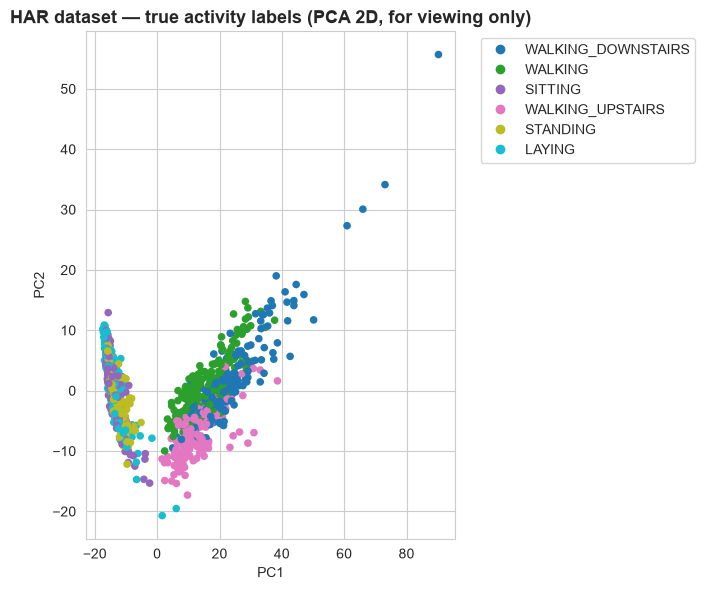

In [5]:
from sklearn.decomposition import PCA

X = X_har_std   # working array for the clustering case study

# 2D PCA projection, purely so we have something to plot cluster assignments on
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_viz.fit_transform(X) # which direction contains the most and least variation

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_har, cmap='tab10', s=20) # all rows of col 0 x axis pc1 then all rows of col 1 pc2
plt.title('HAR dataset — true activity labels (PCA 2D, for viewing only)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(activity_names), bbox_to_anchor=(1.05, 1))
plt.tight_layout(); plt.show()

The PCA projection already shows two loose super-groups

LAYING/SITTING/STANDING are all *static* postures with very similar sensor signatures, while WALKING/WALKING_UPSTAIRS/WALKING_DOWNSTAIRS are all *dynamic* movements. 


## 3. K-Means Clustering

K-Means partitions data into k clusters by repeatedly assigning each point to its nearest centroid, then recomputing centroids, until they stop moving. We tune k using the elbow method (inertia) plus the silhouette score.


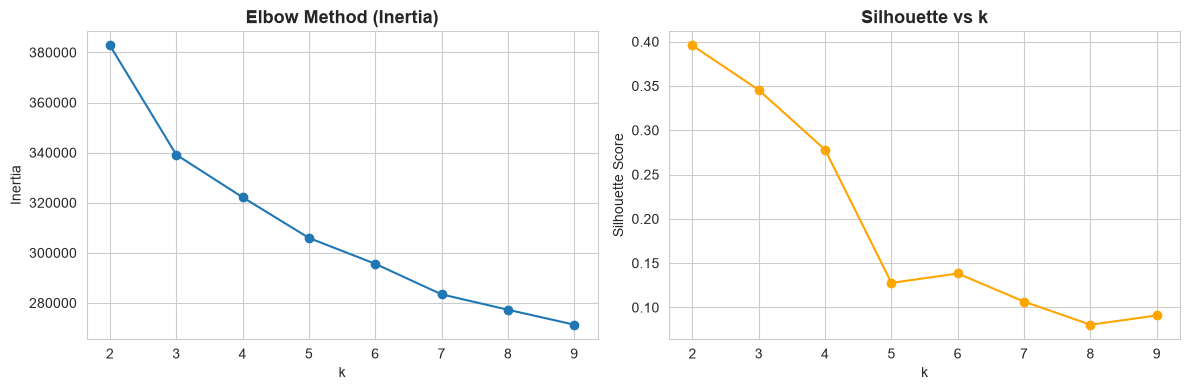

Best k by silhouette: 2  (true number of activities: 6)


In [6]:
inertias, sils = [], [] #store the inertia and silhouette values of each k 
# inertia measures how close the data points are to the center(centroid) of their assigned cluster
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertias.append(km.inertia_) # as k increases inertia always decreases 
    sils.append(silhouette_score(X, km.labels_)) # how far is the point close the points are to other points in the same cluster how far is the pount frin points in other clusters

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), inertias, 'o-'); ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia')
ax[1].plot(list(K_range), sils, 'o-', color='orange'); ax[1].set_title('Silhouette vs k')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

print('Best k by silhouette:', list(K_range)[np.argmax(sils)], ' (true number of activities: 6)')


In [7]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)   # matches the 6 known activities
labels_kmeans = kmeans.fit_predict(X)
print('K-Means cluster sizes:', np.bincount(labels_kmeans))


K-Means cluster sizes: [162   4 377 320 160 177]


## 4. Hierarchical (Agglomerative) Clustering

Builds a tree of nested clusters by repeatedly merging the two closest clusters, starting from every point in its own cluster. We compare linkage methods, then cut the tree at 6 clusters.

We start with every data point as its own cluster and merge the closest clusters together , each merge is recorded. The merges are drawn as trees called dendrogram.


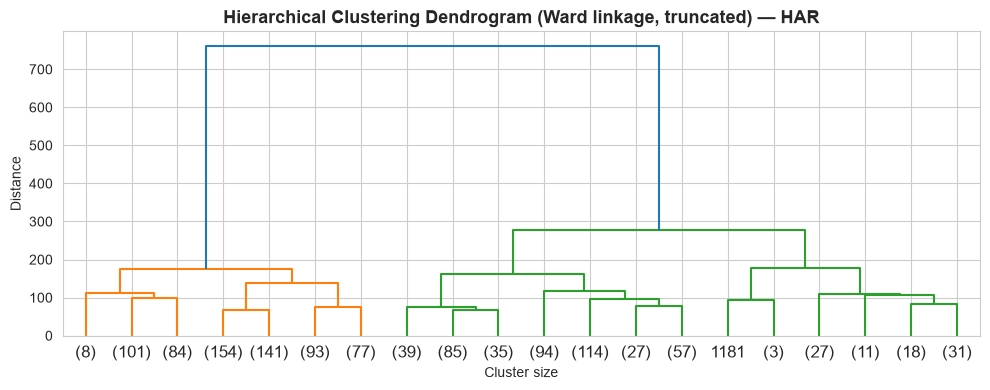

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage # linkage decided which clusters to merge in what order and distance at which they merge
# draw the tree (dendrogram) showing the merging process
from sklearn.cluster import AgglomerativeClustering

Z = linkage(X, method='ward') # ward merges the two clusters that keep the new cluster as compact as possible 
# Z is the linkage matrix stores the entire history of the clustering process
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20)     # truncate for a readable plot
#truncate simplifies the tree only showing the last 20 merged clusters 
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, truncated) — HAR')
plt.xlabel('Cluster size'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()


In [9]:
for linkage_method in ['ward', 'average', 'complete']:
    agg_check = AgglomerativeClustering(n_clusters=6, linkage=linkage_method)
    lbl_check = agg_check.fit_predict(X) # fit the model return the cluster labels 
    print(f'{linkage_method:10s} silhouette = {silhouette_score(X, lbl_check):.3f}')

hier = AgglomerativeClustering(n_clusters=6, linkage='ward')  
labels_hier = hier.fit_predict(X)


ward       silhouette = 0.116
average    silhouette = 0.386
complete   silhouette = 0.361


## 5. DBSCAN

Density-based clustering: groups tightly-packed points and marks sparse points as noise (label -1). We tune `eps` using a k-distance plot instead of guessing.


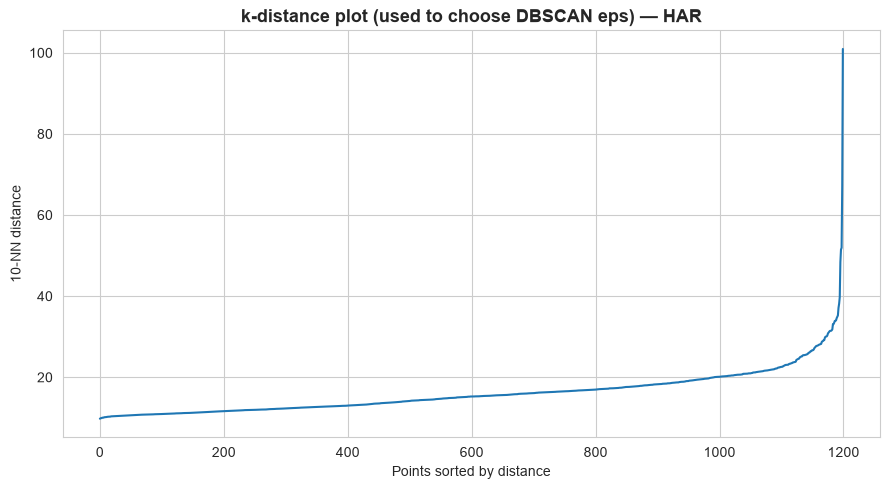

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

min_samples = 10          # a fixed, modest choice given 561 (scaled) input features
neighbors_fit = NearestNeighbors(n_neighbors=min_samples).fit(X) # THE MINIMUMN NUMBER OF NEIGHBOURING POINTS REQUIRED TO FORM A DENSE REGION
# here a point must have atleast 10 nearby points to be considered a part of a dense region
distances, _ = neighbors_fit.kneighbors(X)
k_dist = np.sort(distances[:, -1])

plt.figure()
plt.plot(k_dist)
plt.title('k-distance plot (used to choose DBSCAN eps) — HAR')
plt.xlabel('Points sorted by distance'); plt.ylabel(f'{min_samples}-NN distance')
plt.tight_layout(); plt.show()


In [11]:
best_eps, best_sil, best_labels = None, -1, None
for eps in np.arange(8, 20, 0.5):                          # scan a range of eps around the elbow above
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X) # here dbscan will find the dense regions create clusters marks isolated points as noise 
    lbl = db.labels_ 
    # first set will keep only unique vals so we have x as the no of values in lbl if -1 is in lbl subtract 1 from x and ull get the no of clusters
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_clusters >= 2: # sil score cannot be computed w only 1 cluster
        sil = silhouette_score(X, lbl)
        if sil > best_sil:
            best_sil, best_eps, best_labels = sil, eps, lbl # update

n_found = len(set(best_labels)) - (1 if -1 in best_labels else 0)
print(f'Best eps={best_eps:.2f}, silhouette={best_sil:.3f}, clusters found={n_found}, '
      f'noise points={list(best_labels).count(-1)}')
labels_dbscan = best_labels # can be used to visualise the clusters compare dbscan wi k means and hierarchical count cluster sizes


Best eps=18.00, silhouette=0.305, clusters found=2, noise points=210


## 6. Gaussian Mixture Models (GMM)

Assumes the data comes from a mix of Gaussian distributions and gives each point a probability of belonging to each cluster. We pick the number of components using BIC (lower is better). 

Soft Clustering


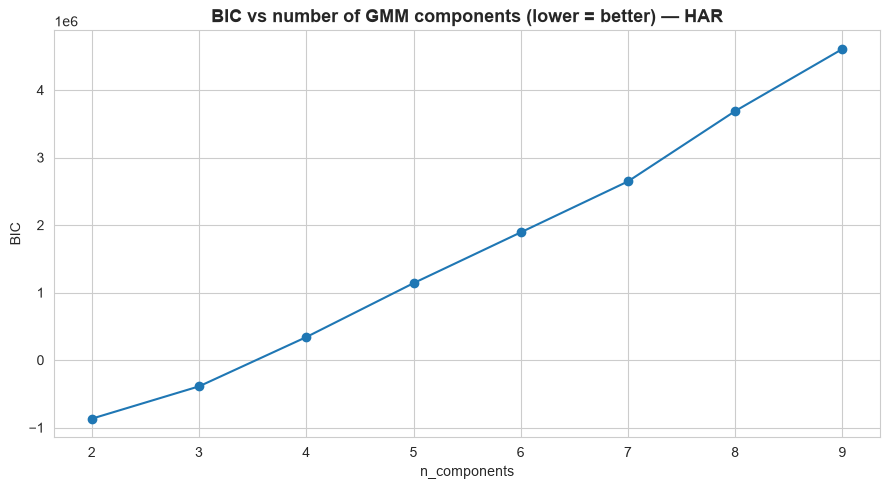

GMM cluster sizes: [299 220 179  42 179 281]


In [12]:
from sklearn.mixture import GaussianMixture

bics = [] #bayesian information criterion helps ans how many gaussian components should be used
comp_range = range(2, 10)
for n in comp_range:
    gmm_check = GaussianMixture(n_components=n, random_state=RANDOM_STATE, n_init=3).fit(X) # trains the model 3 diff times and keeps the best one
    bics.append(gmm_check.bic(X))

plt.figure()
plt.plot(list(comp_range), bics, 'o-')
plt.title('BIC vs number of GMM components (lower = better) — HAR')
plt.xlabel('n_components'); plt.ylabel('BIC')
plt.tight_layout(); plt.show()

gmm = GaussianMixture(n_components=6, random_state=RANDOM_STATE, n_init=3)
labels_gmm = gmm.fit_predict(X)
print('GMM cluster sizes:', np.bincount(labels_gmm))  # counts how many samples belong to each cluster


## 7. Mean Shift

A centroid-based algorithm that does **not** require specifying the number of clusters — it automatically finds dense "modes" by shifting points toward the local mean of their neighborhood. We estimate a reasonable `bandwidth` automatically. 

Start off by estimating the bandwidth, create mean shift model, find dense peak (modes) assign every point to the nearest peal print bandwidth print no of clusters print size of each cluster 


In [13]:
from sklearn.cluster import MeanShift, estimate_bandwidth # helper function to choose bandwidth automatically
# radius around each point 
bandwidth = estimate_bandwidth(X, quantile=0.15, n_samples=500, random_state=RANDOM_STATE)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X)
print(f'Estimated bandwidth: {bandwidth:.2f}')
print('Mean Shift found', len(set(labels_ms)), 'clusters. Sizes:', np.bincount(labels_ms))


Estimated bandwidth: 20.62
Mean Shift found 2 clusters. Sizes: [699 501]


## 8. Comparing All Five Clustering Algorithms

We evaluate every algorithm with four internal metrics (no ground truth needed) — Silhouette, Davies-Bouldin, Calinski-Harabasz, and Inertia (generalized here as the sum of squared distances from each point to its own cluster's centroid, so it can be computed for any labeling, not just K-Means) — plus Adjusted Rand Index (ARI) against the true activity labels as a bonus sanity check, since we happen to have labels for this dataset.


In [14]:
def sse_inertia(data, labels):
    # sum of squared distances from each point to its own cluster's centroid
    # (generalizes K-Means' "inertia" so we can compute it for ANY set of labels,
    # not just K-Means, letting us compare all 5 algorithms on the same metric)
    total = 0.0
    for lbl in set(labels):
        pts = data[labels == lbl]              # all points assigned to this cluster
        total += ((pts - pts.mean(axis=0)) ** 2).sum()   # squared distance to that cluster's centroid
    return total

# collect every algorithm's cluster assignments in one place so we can loop over them
label_sets = {
    'K-Means': labels_kmeans,
    'Hierarchical (Ward)': labels_hier,
    'DBSCAN': labels_dbscan,
    'GMM': labels_gmm,
    'Mean Shift': labels_ms,
}

rows = []
for name, lbl in label_sets.items():
    mask = lbl != -1                      # drop DBSCAN noise points (-1) before scoring
    x, l = X[mask], lbl[mask]              # matching subset of the data and its labels

    rows.append({
        'Algorithm': name,
        'Silhouette': silhouette_score(x, l),             # higher = better-separated clusters
        'DaviesBouldin': davies_bouldin_score(x, l),       # lower = more distinct clusters
        'CalinskiHarabasz': calinski_harabasz_score(x, l), # higher = better between/within cluster ratio
        'Inertia': sse_inertia(x, l),                      # lower = more compact clusters
        'ARI': adjusted_rand_score(y_har[mask], l),        # higher = closer match to true activity labels
        'n_clusters': len(set(l)),                         # how many clusters this algorithm actually found
    })

# turn the list of per-algorithm result dicts into one readable comparison table
results_df = pd.DataFrame(rows).set_index('Algorithm').round(3)
results_df

,Silhouette,DaviesBouldin,CalinskiHarabasz,Inertia,ARI,n_clusters
Algorithm,,,,,,
K-Means,0.138,2.026,305.040,295601.942,0.401,6
Hierarchical (Ward),0.116,2.340,295.850,300683.185,0.296,6
DBSCAN,0.415,1.050,831.259,200359.664,0.322,2
GMM,0.109,2.340,303.383,296505.474,0.408,6
Mean Shift,0.382,1.106,854.833,392868.603,0.283,2


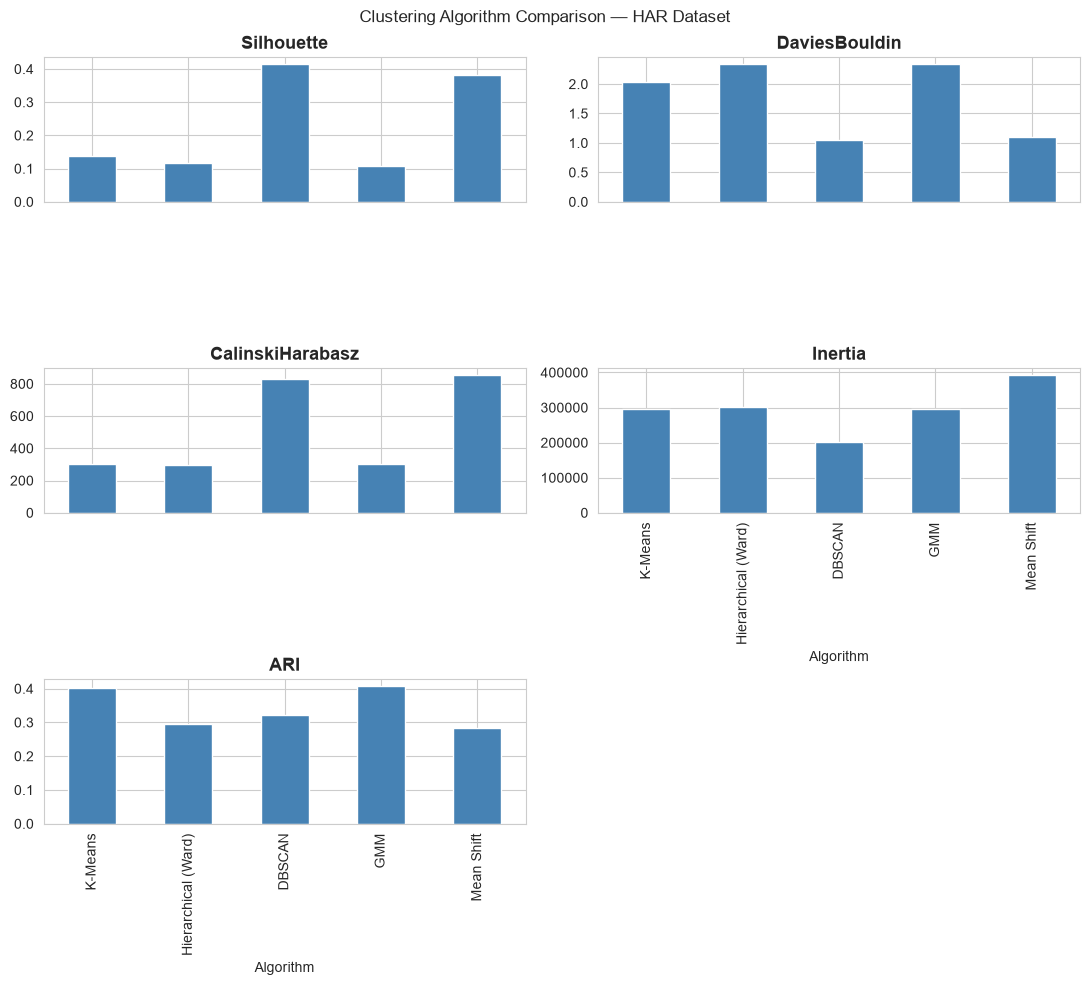

In [15]:
results_df[['Silhouette', 'DaviesBouldin', 'CalinskiHarabasz', 'Inertia', 'ARI']].plot(
    kind='bar', subplots=True, layout=(3, 2), figsize=(11, 10), legend=False, color='steelblue')
plt.suptitle('Clustering Algorithm Comparison — HAR Dataset')
plt.tight_layout(); plt.show()


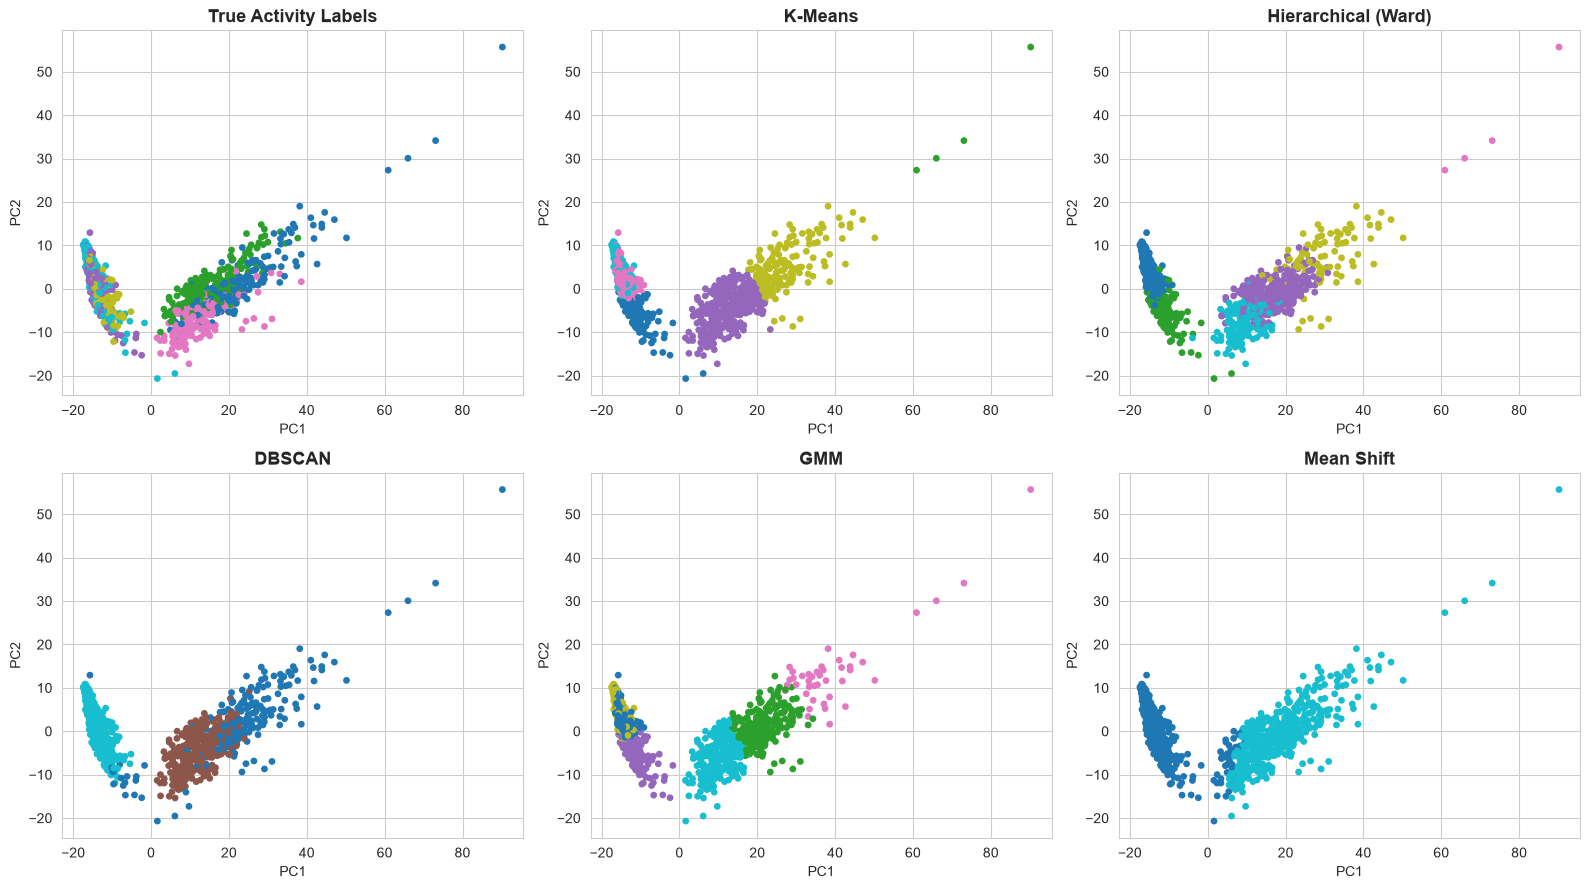

In [16]:
# Visualizing every algorithm's cluster assignment on the same 2D PCA projection
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_har, cmap='tab10', s=15)
axes[0].set_title('True Activity Labels')

for i, (name, lbl) in enumerate(label_sets.items(), start=1):
    axes[i].scatter(X_pca2[:, 0], X_pca2[:, 1], c=lbl, cmap='tab10', s=15)
    axes[i].set_title(name)

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()


### Why does one algorithm perform better?

**K-Means and GMM** tend to lead here (highest Silhouette/Calinski-Harabasz/ARI, lowest Inertia relative to their cluster count). The 6 activities form two broad super-clusters — static postures (`SITTING`/`STANDING`/`LAYING`) and dynamic movements (the 3 `WALKING*` variants) — and within each super-cluster, the classes are roughly convex, similarly-shaped groups in the PCA view, which suits K-Means'/GMM's spherical/Gaussian assumptions reasonably well.

**Hierarchical (Ward)** performs similarly to K-Means, since Ward linkage also merges to minimize within-cluster variance.

**DBSCAN** tends to lump the three static activities together (they genuinely overlap in sensor-signature) and/or produce a lot of noise points, since there isn't a clean density gap separating `SITTING` from `STANDING` from `LAYING`.

**Mean Shift** often collapses to fewer clusters than the true 6, again because the static activities don't form separate density modes.

**Takeaway:** all 5 algorithms do a decent job separating "static" from "dynamic" movement, but struggle in the same way real activity-recognition systems do — telling `SITTING` apart from `STANDING` from sensor data alone is genuinely hard, since the accelerometer/gyroscope signal for both is close to motionless.


## 9. Model Interpretation

Clustering models don't have a "feature importance" in the traditional sense since there's no target to predict. So for interpretation, we train a **supervised** Random Forest — predicting the activity — and interpret that model instead. This mirrors a common real workflow: use unsupervised learning to explore data, then a supervised model + interpretation tools to explain what's actually driving the groups.


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_har_std, y_har, test_size=0.25, random_state=RANDOM_STATE, stratify=y_har)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
print('Test accuracy:', rf.score(X_test, y_test))


Test accuracy: 0.94


### 9.1 Feature Importance (built-in, Gini-based)


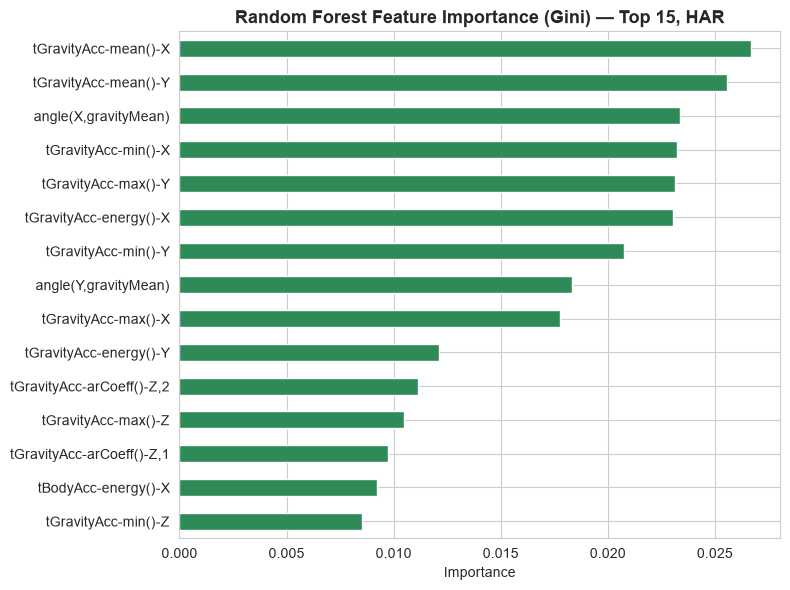

tGravityAcc-mean()-X      0.026703
tGravityAcc-mean()-Y      0.025581
angle(X,gravityMean)      0.023356
tGravityAcc-min()-X       0.023222
tGravityAcc-max()-Y       0.023120
tGravityAcc-energy()-X    0.023050
tGravityAcc-min()-Y       0.020761
angle(Y,gravityMean)      0.018327
tGravityAcc-max()-X       0.017783
tGravityAcc-energy()-Y    0.012097
dtype: float64

In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance (Gini) — Top 15, HAR')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()
importances.head(10)


### 9.2 Permutation Importance

Built-in feature importance can be biased toward high-cardinality/continuous features. Permutation importance instead measures how much test accuracy *drops* when a feature's values are randomly shuffled — a more reliable, model-agnostic check.


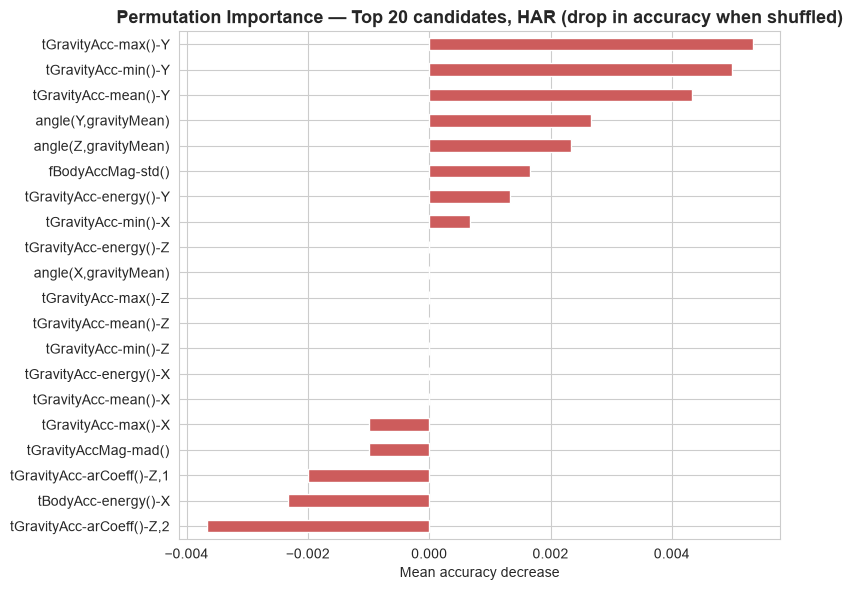

tGravityAcc-max()-Y       0.005333
tGravityAcc-min()-Y       0.005000
tGravityAcc-mean()-Y      0.004333
angle(Y,gravityMean)      0.002667
angle(Z,gravityMean)      0.002333
fBodyAccMag-std()         0.001667
tGravityAcc-energy()-Y    0.001333
tGravityAcc-min()-X       0.000667
tGravityAcc-energy()-Z    0.000000
angle(X,gravityMean)      0.000000
dtype: float64

In [19]:
from sklearn.inspection import permutation_importance

top20 = importances.head(20).index.tolist()

# permutation_importance must be run against the SAME model/feature set it was trained on
# (all 561 features) we just filter down to the top 20 columns afterward for a readable plot
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=feature_cols).loc[top20].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
perm_series.plot(kind='barh', color='indianred')
plt.gca().invert_yaxis()
plt.title('Permutation Importance — Top 20 candidates, HAR (drop in accuracy when shuffled)')
plt.xlabel('Mean accuracy decrease')
plt.tight_layout(); plt.show()
perm_series.head(10)


### 9.3 SHAP (SHapley Additive exPlanations)

SHAP explains *each individual prediction* by fairly attributing credit to each feature (game-theory based), and gives a global summary of which features matter most and in which direction. We restrict the explained features to the same top 20 subset for speed and readability.


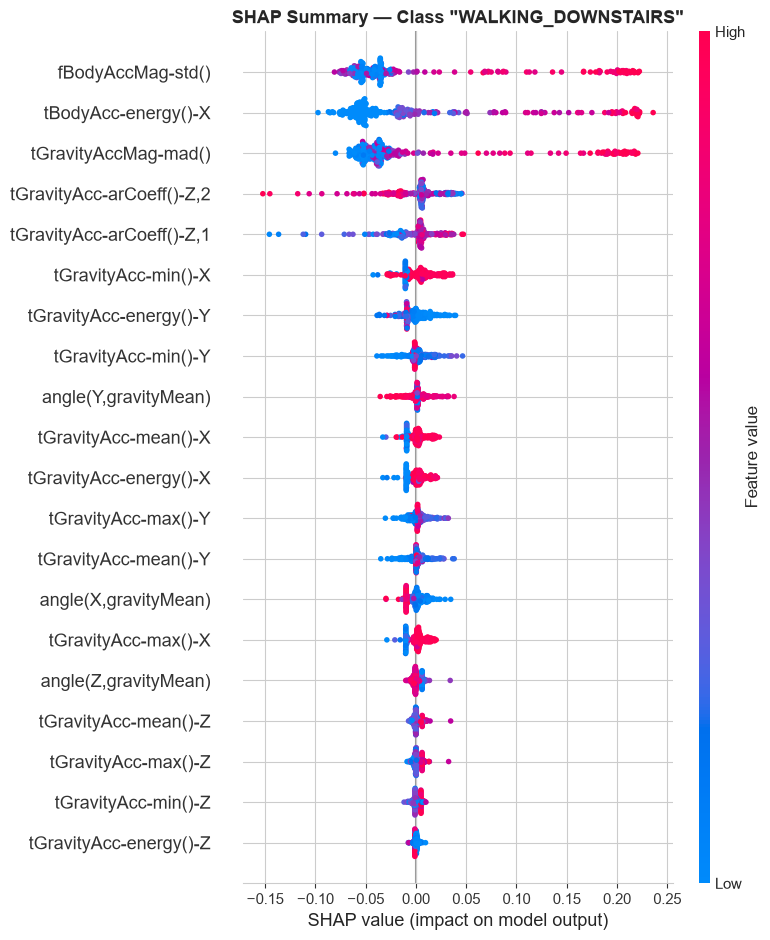

In [20]:
import shap

top20_idx = [feature_cols.index(f) for f in top20]   # column positions for the top-20 features, used just below
X_test_top20 = pd.DataFrame(X_test[:, top20_idx], columns=top20)
rf_top20 = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_top20.fit(pd.DataFrame(X_train[:, top20_idx], columns=top20), y_train)

explainer = shap.TreeExplainer(rf_top20)
shap_values = explainer.shap_values(X_test_top20)

# newer shap versions return one array shaped (n_samples, n_features, n_classes) instead of a list per class
if isinstance(shap_values, list):
    sv_for_plot = shap_values[0]
else:
    sv_for_plot = shap_values[:, :, 0]

shap.summary_plot(sv_for_plot, X_test_top20, show=False)
plt.title(f'SHAP Summary — Class "{activity_names[0]}"')
plt.tight_layout(); plt.show()


### 9.4 Partial Dependence Plot (PDP)

Shows how the model's predicted probability for a class changes as ONE feature varies, holding the others at their observed distribution — useful for seeing the direction/shape of a feature's effect.


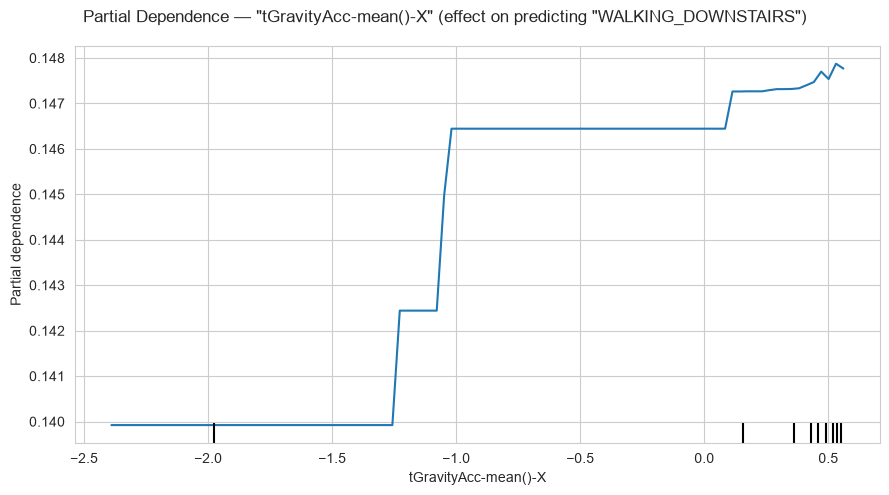

In [21]:
from sklearn.inspection import PartialDependenceDisplay

top_feature = importances.index[0]
top_idx = feature_cols.index(top_feature)

PartialDependenceDisplay.from_estimator(rf, X_train, [top_idx], feature_names=feature_cols, target=0)
plt.suptitle(f'Partial Dependence — "{top_feature}" (effect on predicting "{activity_names[0]}")')
plt.tight_layout(); plt.show()
